In [15]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/07_exam_scores.csv")

df.head()


,math_score,science_score,english_score,study_hours,final_score
0,62.0,78.0,69.0,10.2,82.9
1,38.0,84.0,38.0,8.2,64.5
2,22.0,36.0,85.0,10.3,59.9
3,99.0,71.0,92.0,11.3,96.9
4,39.0,28.0,46.0,5.0,40.6


In [18]:
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Shape of dataset: (1020, 5)

Column names:
['math_score', 'science_score', 'english_score', 'study_hours', 'final_score']

Data types:
math_score       float64
science_score    float64
english_score    float64
study_hours      float64
final_score      float64
dtype: object


In [19]:
df.describe()

,math_score,science_score,english_score,study_hours,final_score
count,1010.000000,1010.000000,1009.000000,1010.000000,1020.000000
mean,60.463366,59.650495,60.889990,6.577228,68.416765
std,24.190013,23.639169,23.157432,3.126268,14.509187
min,20.000000,-10.000000,20.000000,-4.000000,22.200000
25%,40.000000,40.000000,41.000000,4.000000,58.475000
50%,60.000000,59.000000,61.000000,6.600000,68.250000
75%,80.000000,80.000000,81.000000,9.200000,78.700000
max,150.000000,100.000000,100.000000,12.000000,109.900000


In [20]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())


Missing values:
math_score       10
science_score    10
english_score    11
study_hours      10
final_score       0
dtype: int64

Duplicate rows:
20


In [45]:
df.duplicated().sum()

np.int64(20)

In [22]:
score_columns = [
    "math_score",
    "science_score",
    "english_score",
    "final_score"
]

for column in score_columns:
    above_100 = (df[column] > 100).sum()
    negative = (df[column] < 0).sum()

    print(f"{column}:")
    print(f"  Scores above 100: {above_100}")
    print(f"  Negative scores: {negative}")

math_score:
  Scores above 100: 5
  Negative scores: 0
science_score:
  Scores above 100: 0
  Negative scores: 5
english_score:
  Scores above 100: 0
  Negative scores: 0
final_score:
  Scores above 100: 14
  Negative scores: 0


In [23]:
Q1 = df["study_hours"].quantile(0.25)
Q3 = df["study_hours"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["study_hours"] < lower_bound) |
    (df["study_hours"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of study-hours outliers:", len(outliers))

Q1: 4.0
Q3: 9.2
IQR: 5.199999999999999
Lower bound: -3.799999999999999
Upper bound: 17.0
Number of study-hours outliers: 5


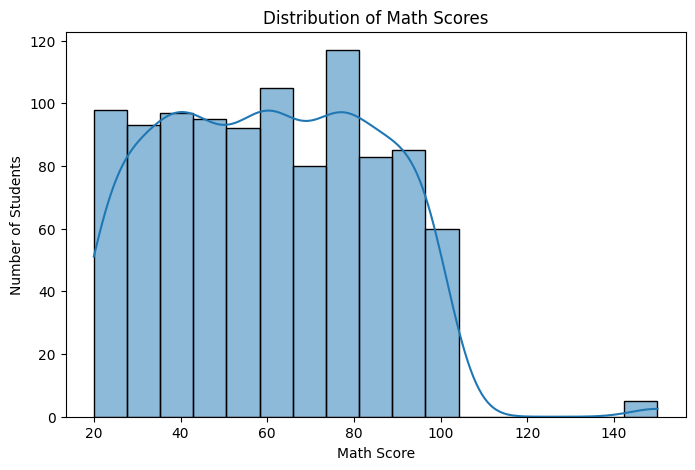

In [24]:
plt.figure(figsize=(8, 5))
sns.histplot(df["math_score"], kde=True)
plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Number of Students")
plt.show()


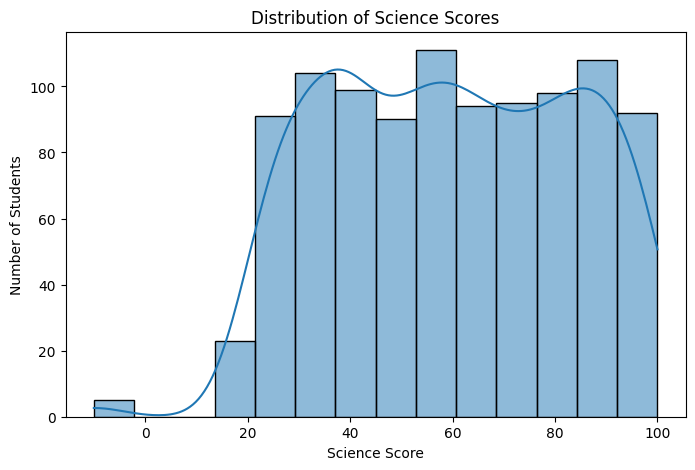

In [25]:
plt.figure(figsize=(8, 5))
sns.histplot(df["science_score"], kde=True)
plt.title("Distribution of Science Scores")
plt.xlabel("Science Score")
plt.ylabel("Number of Students")
plt.show()

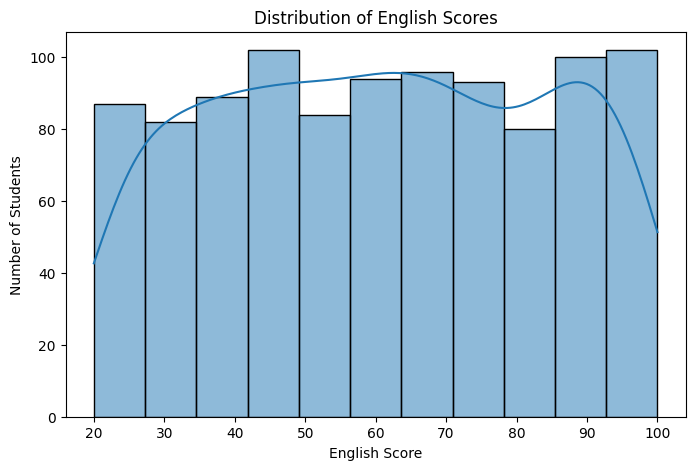

In [26]:
plt.figure(figsize=(8, 5))
sns.histplot(df["english_score"], kde=True)
plt.title("Distribution of English Scores")
plt.xlabel("English Score")
plt.ylabel("Number of Students")
plt.show()

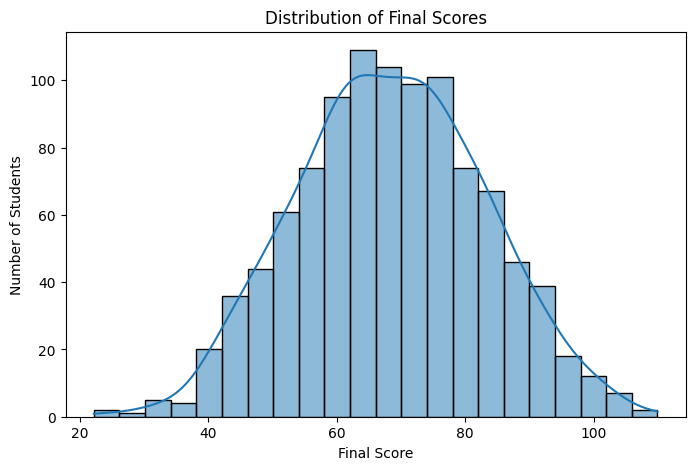

In [27]:
plt.figure(figsize=(8, 5))
sns.histplot(df["final_score"], kde=True)
plt.title("Distribution of Final Scores")
plt.xlabel("Final Score")
plt.ylabel("Number of Students")
plt.show()

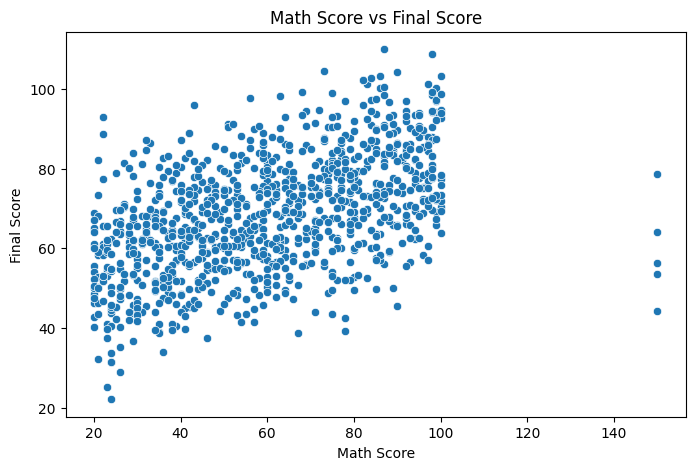

In [28]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="math_score", y="final_score")
plt.title("Math Score vs Final Score")
plt.xlabel("Math Score")
plt.ylabel("Final Score")
plt.show()

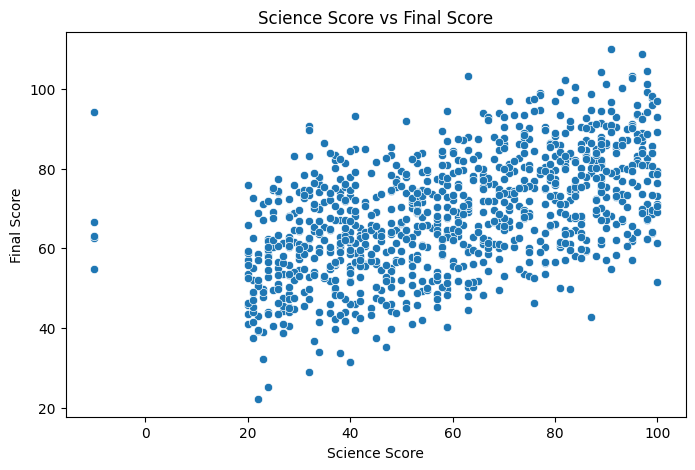

In [29]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="science_score", y="final_score")
plt.title("Science Score vs Final Score")
plt.xlabel("Science Score")
plt.ylabel("Final Score")
plt.show()

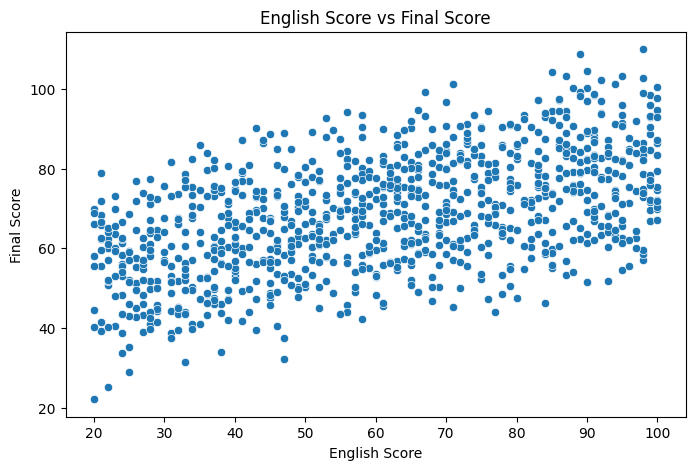

In [30]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="english_score", y="final_score")
plt.title("English Score vs Final Score")
plt.xlabel("English Score")
plt.ylabel("Final Score")
plt.show()

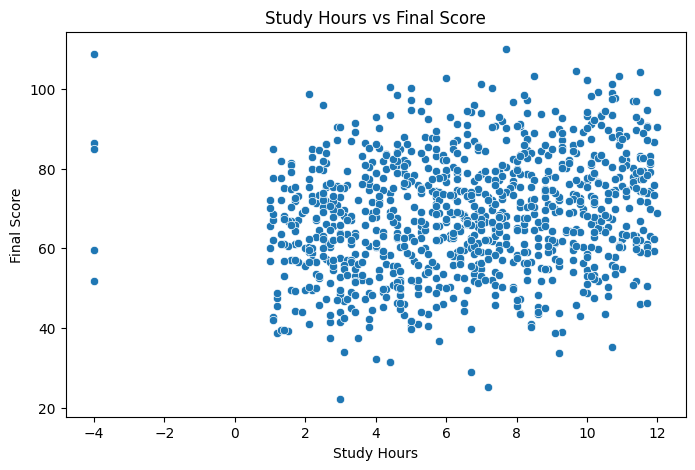

In [31]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="study_hours", y="final_score")
plt.title("Study Hours vs Final Score")
plt.xlabel("Study Hours")
plt.ylabel("Final Score")
plt.show()

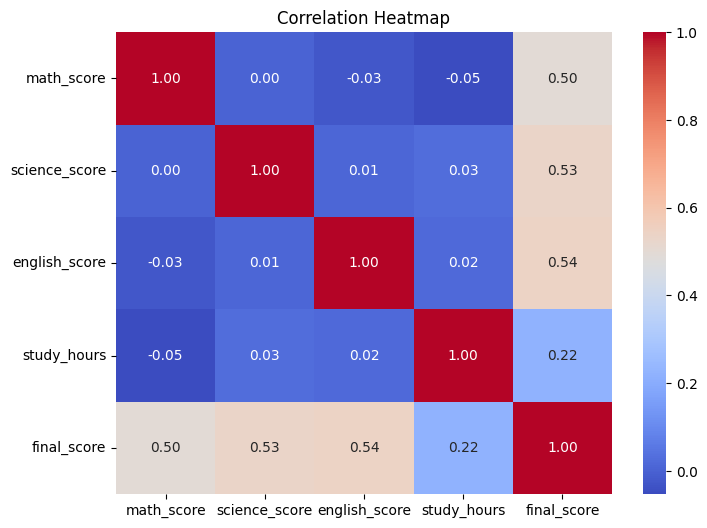

In [32]:
plt.figure(figsize=(8, 6))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [50]:
clean_df = df.copy()

In [34]:
clean_df = clean_df.drop_duplicates()

In [49]:
score_columns = [
    "math_score",
    "science_score",
    "english_score",
    "final_score"
]

for column in score_columns:
    clean_df.loc[
        (clean_df[column] < 0) | (clean_df[column] > 100),
        column
    ] = np.nan

In [36]:
for column in score_columns + ["study_hours"]:
    clean_df[column] = clean_df[column].fillna(clean_df[column].median())

In [37]:
clean_df["study_hours"] = clean_df["study_hours"].clip(
    lower=lower_bound,
    upper=upper_bound
)

In [38]:
print("Missing values after cleaning:")
print(clean_df.isnull().sum())

print("\nDuplicate rows after cleaning:")
print(clean_df.duplicated().sum())

print("\nMinimum scores:")
print(clean_df[score_columns].min())

print("\nMaximum scores:")
print(clean_df[score_columns].max())

print("\nMaximum study hours:")
print(clean_df["study_hours"].max())

Missing values after cleaning:
math_score       0
science_score    0
english_score    0
study_hours      0
final_score      0
dtype: int64

Duplicate rows after cleaning:
0

Minimum scores:
math_score       20.0
science_score    20.0
english_score    20.0
final_score      22.2
dtype: float64

Maximum scores:
math_score       100.0
science_score    100.0
english_score    100.0
final_score       99.3
dtype: float64

Maximum study hours:
12.0


In [48]:
clean_df["average_subject_score"] = clean_df[
    ["math_score", "science_score", "english_score"]
].mean(axis=1)

In [40]:
clean_df["total_subject_score"] = clean_df[
    ["math_score", "science_score", "english_score"]
].sum(axis=1)

In [47]:
clean_df["study_efficiency"] = (
    clean_df["final_score"] /
    clean_df["study_hours"].replace(0, np.nan)
)

In [42]:
clean_df["study_efficiency"] = clean_df["study_efficiency"].fillna(0)

In [43]:
X = clean_df.drop(columns=["final_score"])

y = clean_df["final_score"]
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nX columns:")
print(X.columns.tolist())

print("\ny:")
print(y.head())

X shape: (1000, 7)
y shape: (1000,)

X columns:
['math_score', 'science_score', 'english_score', 'study_hours', 'average_subject_score', 'total_subject_score', 'study_efficiency']

y:
0    82.9
1    64.5
2    59.9
3    96.9
4    40.6
Name: final_score, dtype: float64


In [44]:
print("Final dataset shape:", clean_df.shape)

print("\nFinal columns:")
print(clean_df.columns.tolist())

print("\nX shape:", X.shape)
print("y shape:", y.shape)

print("\nFirst 5 rows of cleaned dataset:")
display(clean_df.head())

Final dataset shape: (1000, 8)

Final columns:
['math_score', 'science_score', 'english_score', 'study_hours', 'final_score', 'average_subject_score', 'total_subject_score', 'study_efficiency']

X shape: (1000, 7)
y shape: (1000,)

First 5 rows of cleaned dataset:


,math_score,science_score,english_score,study_hours,final_score,average_subject_score,total_subject_score,study_efficiency
0,62.0,78.0,69.0,10.2,82.9,69.666667,209.0,8.127451
1,38.0,84.0,38.0,8.2,64.5,53.333333,160.0,7.865854
2,22.0,36.0,85.0,10.3,59.9,47.666667,143.0,5.815534
3,99.0,71.0,92.0,11.3,96.9,87.333333,262.0,8.575221
4,39.0,28.0,46.0,5.0,40.6,37.666667,113.0,8.120000
